<a id="top"></a>

# Spatial Inequalities in Violent Crime Across London: Examining the Relationship Between Violence Rates and Deprivation at Borough Level

**CASA0006 – Data Science for Spatial Systems**  
**Student Number: 24080728**

### Preparation

- **GitHub repository (data):** https://github.com/Troy-JZ/CASA0006
- **Number of words:** approximately 1,497, excluding tables, reference list and codes/comments
- **Runtime:** mostly under 2 minutes
- **Coding environment:** Jupyter, using `pandas`, `numpy`, `geopandas`, `matplotlib`, `seaborn`, `scipy`, `statsmodels` and `mapclassify`
- **Licence:** this notebook is made available under the Creative Commons Attribution licence

All four source files are read remotely from the GitHub repository listed above, so the notebook executes end to end without any local file paths.

### Table of contents

1. [Introduction](#sec1)
2. [Research questions](#sec2)
3. [Data](#sec3)
4. [Methodology](#sec4)
5. [Results and discussion](#sec5)
6. [Conclusion](#sec6)
7. [References](#sec7)

---

<a id="sec1"></a>
## 1. Introduction

[go back to the top](#top)

Crime is not spread evenly across urban areas. Early ecological research showed that offending tends to be concentrated in socially disadvantaged neighbourhoods rather than random (Shaw & McKay, 1942). Later studies also highlight the importance of neighbourhood social organisation, collective efficacy and structural disadvantage in explaining patterns of violence and disorder (Sampson et al., 1997). However, scale matters too: relationships found at one geographic level may become weaker at another, so borough-level results should be understood as showing broad urban inequalities rather than detailed neighbourhood processes (Hipp, 2007).

This analysis focuses on one specific offence group: violence against the person, instead of total recorded crime. This makes the research question clearer because the link between structural disadvantage and crime is strongest for interpersonal violence. Total recorded crime combines offences such as theft and vehicle crime, which are often shaped more by commercial activity and daytime movement than by resident deprivation. Including all crime types together could therefore weaken the relationship being studied.

London is a perfect case for this analysis because its boroughs vary clearly in deprivation, population density and social composition. The London Datastore provides consistent borough-level crime counts and official boundary files. Following guidance, crime counts are converted into rates per 1,000 residents, since rates are more meaningful than raw counts. The analysis include choropleth mapping, correlation, regression and robustness checks.

<a id="sec2"></a>
## 2. Research questions

[go back to the top](#top)

**Question 1.** Which London boroughs have the highest and lowest rates of violence against the person per 1,000 residents?

**Question 2.** Is there a statistically significant association between borough-level violence rates and deprivation, measured by the IMD 2019 average score?

**Question 3.** To what extent can deprivation explain spatial variation in violence rates across London boroughs?

<a id="sec3"></a>
## 3. Data

[go back to the top](#top)

### 3.1 Sources

All data are official UK open data published under the Open Government Licence.

| Source | Provider (country) | Description | URL |
|---|---|---|---|
| MPS Recorded Crime: Geographic Breakdown | Metropolitan Police Service / GLA (UK) | Monthly recorded offences by borough and offence group | https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m |
| Estimates of the population for England and Wales, mid-2023 | Office for National Statistics (UK) | Mid-year resident population by local authority | https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/estimatesofthepopulationforenglandandwales |
| English Indices of Deprivation 2019 (London file) | MHCLG, published via the GLA (UK) | Borough-level IMD summary measures | https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g |
| Statistical GIS Boundary Files for London | Greater London Authority (UK) | Borough polygons, OSGB36 / British National Grid | https://data.london.gov.uk/dataset/statistical-gis-boundary-files-london |

### 3.2 Preprocessing decisions

**Offence group.** The crime file is filtered to the `VIOLENCE AGAINST THE PERSON` major group, covering homicide, violence with and without injury, stalking and harassment, and death or serious injury by illegal driving.


**Reference year.** The twelve monthly columns for 2023 are summed to an annual borough total. 2023 is the most recent *complete* calendar year in a file running from July 2020 to June 2024, and matches the mid-2023 population estimates, aligning numerator and denominator.

**Non-borough units.** Two MPS reporting units, `Unknown` and `London Heathrow and London City Airports`, are removed as no resident population exists to normalise them.

**Join key.** Population and deprivation are joined on the ONS GSS code rather than borough name, since official datasets use inconsistent text labels for the same authority.

The City of London is policed by the City of London Police and does not appear in MPS records at all. Its absence from the models follows from data coverage rather than a judgement about outliers, leaving 32 boroughs. It is retained in the mapped data as missing so the map stays complete.


### 3.3 Variables used in analysis

| Variable | Type | Description | Role |
|---|---|---|---|
| `gss_code` | identifier | ONS statistical area code | Merge key only |
| `borough` | identifier | London borough name | Labelling only |
| `violence_count_2023` | numeric | Recorded offences of violence against the person, 2023 | Rate numerator |
| `population_2023` | numeric | ONS mid-2023 resident population | Rate denominator |
| `violence_rate_per_1000` | numeric | Offences per 1,000 residents | Dependent variable |
| `imd_score_2019` | numeric | IMD 2019 average score; higher = more deprived | Explanatory variable |

Identifier columns are used for merging and labelling only and never enter a model. No categorical variable is treated as numeric.

In [ ]:
# Core libraries
import io, zipfile, tempfile, urllib.request, os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# All source files are hosted in the accompanying GitHub repository
BASE = "https://raw.githubusercontent.com/Troy-JZ/CASA0006/main/"

CRIME_URL = BASE + "MPS%20Borough%20Level%20Crime%20%28Historical%29.csv"
IMD_URL   = BASE + "ID%202019%20for%20London.xlsx"
POP_URL   = BASE + "mye23tablesew.xlsx"
GEO_URL   = BASE + "London_Borough_Excluding_MHW.zip"

In [ ]:
# Load the three tabular sources directly from GitHub
crime_raw = pd.read_csv(CRIME_URL)
imd_raw   = pd.read_excel(IMD_URL, sheet_name="Borough summary measures")
pop_raw   = pd.read_excel(POP_URL, sheet_name="MYE2 - Persons", header=7)

print("Crime file :", crime_raw.shape, "| columns:", crime_raw.columns[:3].tolist(), "...")
print("IMD file   :", imd_raw.shape)
print("Population :", pop_raw.shape)

# Which calendar years are complete in the crime file?
month_cols = [c for c in crime_raw.columns if c.isdigit()]
year_coverage = pd.Series([m[:4] for m in month_cols]).value_counts().sort_index()
print("\nMonths available per calendar year:")
print(year_coverage.to_string())

Crime file : (1125, 51) | columns: ['Group', 'SubGroup', 'BOCU'] ...
IMD file   : (33, 12)
Population : (357, 95)

Months available per calendar year:
2020     6
2021    12
2022    12
2023    12
2024     6


In [ ]:
# ---- 1. Crime: violence against the person, calendar year 2023 -------------
months_2023 = [c for c in month_cols if c.startswith("2023")]

violence = crime_raw[crime_raw["Group"] == "VIOLENCE AGAINST THE PERSON"]
crime_borough = (violence.groupby("BOCU")[months_2023].sum().sum(axis=1)
                         .reset_index())
crime_borough.columns = ["borough", "violence_count_2023"]

# Two reporting units in the MPS file are not London boroughs and are removed
non_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime_borough = crime_borough[~crime_borough["borough"].isin(non_boroughs)]

# ---- 2. Population: ONS mid-2023 resident estimates -------------------------
pop_borough = pop_raw.loc[pop_raw["Geography"] == "London Borough",
                          ["Code", "Name", "All ages"]].copy()
pop_borough.columns = ["gss_code", "borough", "population_2023"]

# ---- 3. Deprivation: IMD 2019 borough average score -------------------------
imd_raw.columns = [str(c).strip() for c in imd_raw.columns]   # trailing spaces in headers
imd_borough = imd_raw[["Local Authority District code (2019)",
                       "IMD - Average score"]].copy()
imd_borough.columns = ["gss_code", "imd_score_2019"]

# ---- 4. Merge and derive the rate -------------------------------------------
# Population and deprivation are joined on GSS code (a stable statistical
# identifier), which avoids the borough-name spelling mismatches that arise
# when joining official datasets on text labels.
df = (pop_borough
      .merge(imd_borough, on="gss_code", how="left")
      .merge(crime_borough, on="borough", how="left"))

df["violence_rate_per_1000"] = (df["violence_count_2023"]
                                / df["population_2023"] * 1000).round(2)
df = df.sort_values("borough").reset_index(drop=True)

print("Analysis table:", df.shape)

Analysis table: (33, 6)


In [ ]:
# Reconciliation and completeness checks
print("Boroughs in crime data but not in population data:",
      sorted(set(crime_borough["borough"]) - set(pop_borough["borough"])))
print("Boroughs in population data but not in crime data:",
      sorted(set(pop_borough["borough"]) - set(crime_borough["borough"])))
print("\nMissing values per column:")
print(df.isna().sum().to_string())

# City of London is policed by the City of London Police, not the MPS, so it has
# no entry in this dataset. It is retained for mapping and excluded from models.
df_model = df.dropna(subset=["violence_rate_per_1000"]).copy()
print(f"\nBoroughs used in statistical models: {len(df_model)}")
df.head()

Boroughs in crime data but not in population data: []
Boroughs in population data but not in crime data: ['City of London']

Missing values per column:
gss_code                  0
borough                   0
population_2023           0
imd_score_2019            0
violence_count_2023       1
violence_rate_per_1000    1

Boroughs used in statistical models: 32


,gss_code,borough,population_2023,imd_score_2019,violence_count_2023,violence_rate_per_1000
0,E09000002,Barking and Dagenham,222308,32.768,7013.0,31.55
1,E09000003,Barnet,395007,16.148,7965.0,20.16
2,E09000004,Bexley,250853,16.273,5852.0,23.33
3,E09000005,Brent,344521,25.558,9678.0,28.09
4,E09000006,Bromley,331162,14.163,6935.0,20.94


<a id="sec4"></a>
## 4. Methodology

[go back to the top](#top)

Four methods are used, each tied to a research question, within the maximum permitted.

**1. Rate normalisation and choropleth mapping.** Crime counts are converted into offences per 1,000 residents and mapped using quantile classification. A ranked bar chart is also used for support (Question 1). This helps show the spatial pattern clearly, rather than presenting the results only in a table.

**2. Correlation analysis.** Pearson's *r* measures the linear relationship between the violence rate and IMD score, while Spearman's rank correlation is reported alongside it (Question 2). Pearson's *r* can be affected by a small number of extreme values in a sample of 32 boroughs, whereas the rank measure is less sensitive to this issue. Using both measures helps show whether the relationship depends on particular boroughs.

**3. OLS regression with diagnostics.** OLS regression estimates how much cross-borough variation is associated with deprivation (Question 3). The coefficient can be read as the change in offences per 1,000 residents for each additional IMD point. The model is also checked using formal diagnostics: Breusch–Pagan for heteroscedasticity and Shapiro–Wilk for residual normality.

**4. Robustness checks.** Three alternative specifications test whether the OLS result depends on the distribution of the data or on influential observations. These are a log-linear model for a right-skewed outcome, a Huber robust regression that reduces the influence of unusual observations, and a refit excluding the most influential borough. All three are reported, rather than only the most favourable result.

The models are estimated at borough level, so they describe ecological associations only. No causal claim is made.

<a id="sec5"></a>
## 5. Results and discussion

[go back to the top](#top)

### 5.1 Spatial distribution of violence rates (Question 1)

Boundary polygons: 33 | CRS: OSGB36 / British National Grid
Polygons matched to attribute data: 33


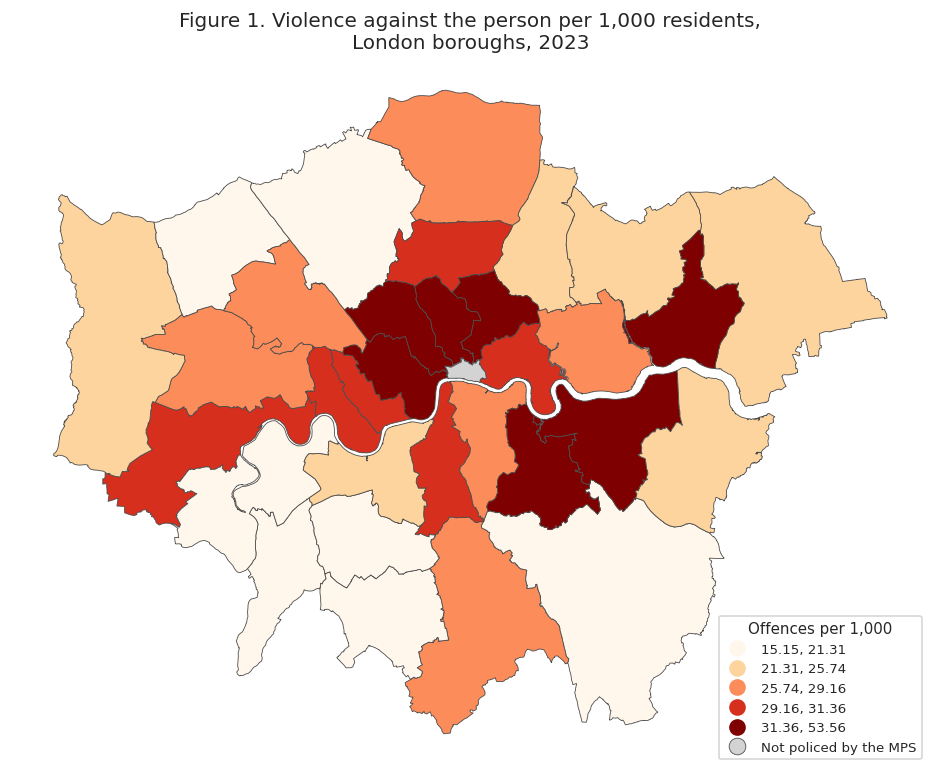

In [ ]:
# Borough boundaries (GLA statistical GIS boundary files)
tmp_zip = os.path.join(tempfile.gettempdir(), "london_boroughs.zip")
urllib.request.urlretrieve(GEO_URL, tmp_zip)
boroughs = gpd.read_file("zip://" + tmp_zip)

map_gdf = boroughs.merge(df, left_on="GSS_CODE", right_on="gss_code", how="left")
print("Boundary polygons:", len(boroughs), "| CRS:", boroughs.crs.name)
print("Polygons matched to attribute data:", map_gdf["gss_code"].notna().sum())

fig, ax = plt.subplots(figsize=(8, 8))
map_gdf.plot(column="violence_rate_per_1000", cmap="OrRd", scheme="quantiles", k=5,
             linewidth=0.5, edgecolor="0.3", legend=True, ax=ax,
             legend_kwds={"title": "Offences per 1,000", "loc": "lower right",
                          "fontsize": 8, "title_fontsize": 9},
             missing_kwds={"color": "lightgrey", "edgecolor": "0.3",
                           "label": "Not policed by the MPS"})
ax.set_title("Figure 1. Violence against the person per 1,000 residents,\n"
             "London boroughs, 2023", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

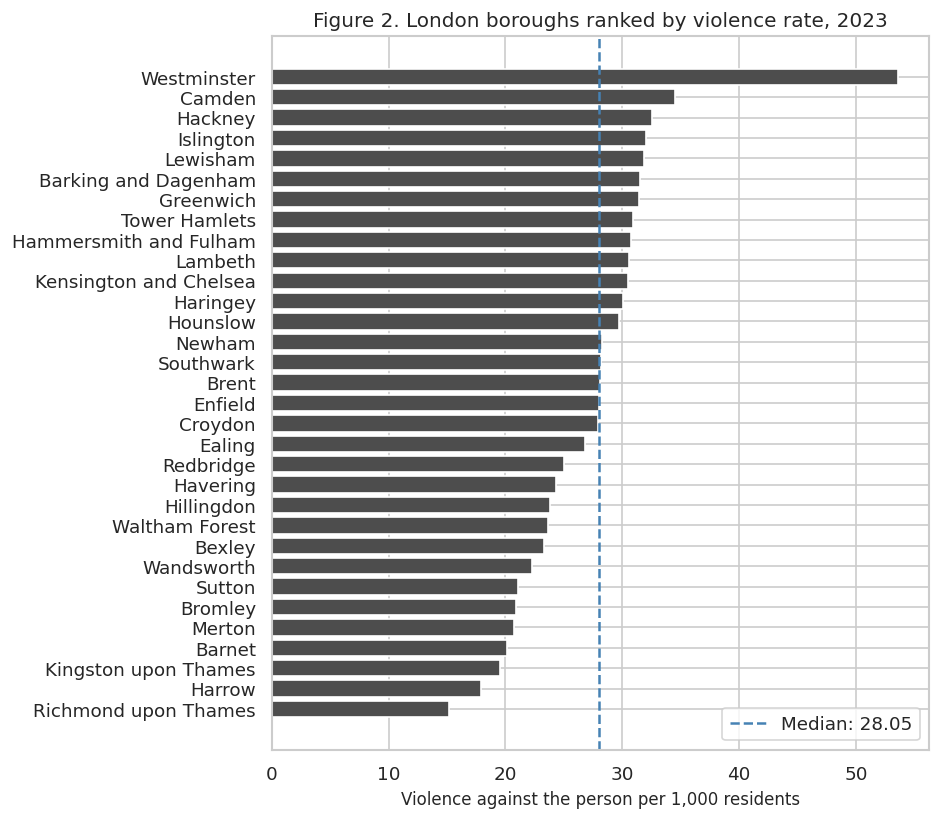

Distribution of borough violence rates (n = 32):
count    32.00
mean     27.35
std       6.87
min      15.15
25%      23.06
50%      28.05
75%      30.80
max      53.56
Skewness: 1.46

Highest five:
    borough  violence_rate_per_1000  imd_score_2019
Westminster                   53.56          20.339
     Camden                   34.49          20.131
    Hackney                   32.54          32.526
  Islington                   32.02          27.535
   Lewisham                   31.86          26.661

Lowest five:
             borough  violence_rate_per_1000  imd_score_2019
              Merton                   20.69          14.649
              Barnet                   20.16          16.148
Kingston upon Thames                   19.49          11.381
              Harrow                   17.92          15.031
Richmond upon Thames                   15.15           9.425


In [ ]:
# Ranked bar chart of borough violence rates
ranked = df_model.sort_values("violence_rate_per_1000", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(ranked["borough"][::-1], ranked["violence_rate_per_1000"][::-1],
        color="#4d4d4d")
ax.axvline(df_model["violence_rate_per_1000"].median(), color="steelblue",
           linestyle="--",
           label=f"Median: {df_model['violence_rate_per_1000'].median():.2f}")
ax.set_xlabel("Violence against the person per 1,000 residents")
ax.set_title("Figure 2. London boroughs ranked by violence rate, 2023")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Distribution of borough violence rates (n = %d):" % len(df_model))
print(df_model["violence_rate_per_1000"].describe().apply(lambda v: f"{v:.2f}").to_string())
print(f"Skewness: {stats.skew(df_model['violence_rate_per_1000']):.2f}")
print("\nHighest five:")
print(ranked[["borough", "violence_rate_per_1000", "imd_score_2019"]]
      .head(5).to_string(index=False))
print("\nLowest five:")
print(ranked[["borough", "violence_rate_per_1000", "imd_score_2019"]]
      .tail(5).to_string(index=False))

Violence rates are unevenly distributed across London boroughs rather than randomly scattered. Across the 32 MPS boroughs, the mean rate is 27.35 offences per 1,000 residents (SD 6.87). The distribution is right-skewed (skewness 1.46), and the highest borough records 3.5 times the rate of the lowest.

Westminster stands clearly apart at 53.56 offences per 1,000, followed by Camden (34.49), Hackney (32.54), Islington (32.02) and Lewisham (31.86). The lowest rates are in outer boroughs: Richmond upon Thames (15.15), Harrow (17.92), Kingston upon Thames (19.49), Barnet (20.16) and Merton (20.69).

Figure 1 shows that the pattern is spatially structured. The highest rates are concentrated in central, inner-east and inner-south-east London, while the lowest rates form an outer ring, especially in south-western and north-western boroughs. This fits the expectation that crime is concentrated in particular parts of a city (Shaw & McKay, 1942). Westminster also shows why resident deprivation is unlikely to be the only factor. Its resident population is small compared with its daytime and visitor population, so the rate may be affected by people who use the borough but do not live there. Section 5.3 returns to this issue.

### 5.2 Association between violence rates and deprivation (Question 2)

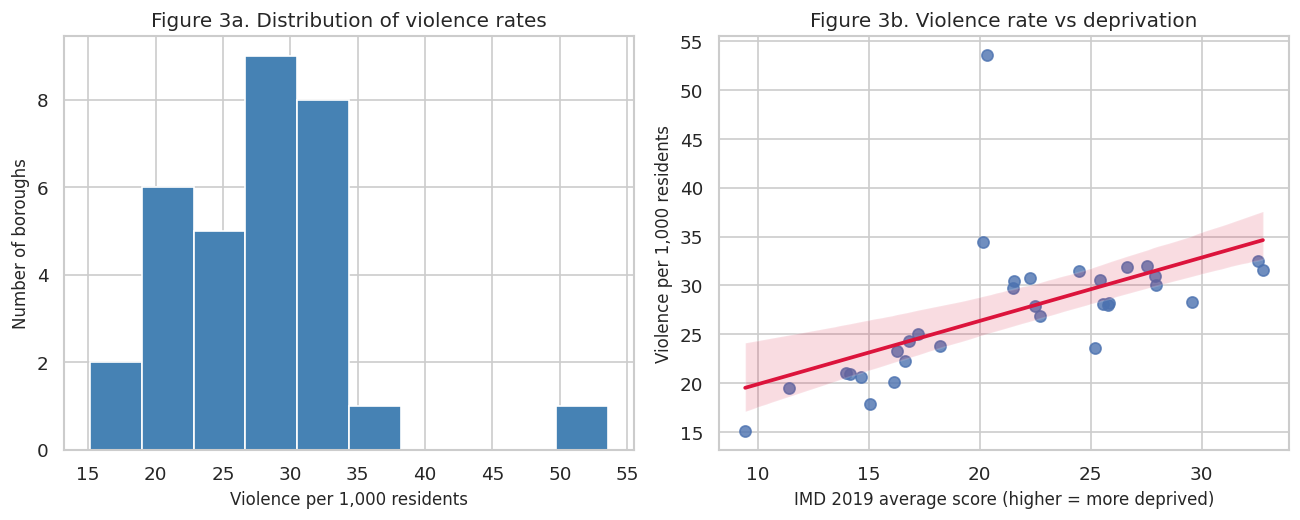

Pearson  r   = 0.570   p = 0.00066
Spearman rho = 0.746   p = 0.00000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(df_model["violence_rate_per_1000"], bins=10,
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Violence per 1,000 residents")
axes[0].set_ylabel("Number of boroughs")
axes[0].set_title("Figure 3a. Distribution of violence rates")

sns.regplot(data=df_model, x="imd_score_2019", y="violence_rate_per_1000",
            ax=axes[1], scatter_kws={"s": 45, "alpha": 0.8},
            line_kws={"color": "crimson"})
axes[1].set_xlabel("IMD 2019 average score (higher = more deprived)")
axes[1].set_ylabel("Violence per 1,000 residents")
axes[1].set_title("Figure 3b. Violence rate vs deprivation")
plt.tight_layout()
plt.show()

r, p_r = stats.pearsonr(df_model["imd_score_2019"],
                        df_model["violence_rate_per_1000"])
rho, p_s = stats.spearmanr(df_model["imd_score_2019"],
                           df_model["violence_rate_per_1000"])
print(f"Pearson  r   = {r:.3f}   p = {p_r:.5f}")
print(f"Spearman rho = {rho:.3f}   p = {p_s:.5f}")

There is a positive and statistically significant relationship between deprivation and the violence rate: Pearson r = 0.570 (p < 0.001), and Spearman rho = 0.746 (p < 0.001). This means that boroughs with higher IMD scores tend to record higher rates of violence against the person.

The difference between the two coefficients is useful to interpret. Because the rank correlation is much larger, the order of boroughs by deprivation is more closely matched to their order by violence than a simple straight-line relationship suggests. This points to a few boroughs sitting away from an otherwise clear pattern, rather than the relationship itself being weak. Figure 3a confirms the right-skew, while Figure 3b shows the upward slope with some outlying points above it.

The answer to research Question 2 is affirmative, with the qualification that the linear association is sensitive to a small number of boroughs, which section 5.3 tests directly.

### 5.3 Explaining spatial variation with regression (Question 3)

In [ ]:
X = sm.add_constant(df_model["imd_score_2019"])
y = df_model["violence_rate_per_1000"]

ols = sm.OLS(y, X).fit()
print(ols.summary().tables[1])
print(f"\nR-squared: {ols.rsquared:.3f}    Adjusted R-squared: {ols.rsquared_adj:.3f}")

# Assumption checks
bp_p = het_breuschpagan(ols.resid, X)[1]
sw_p = stats.shapiro(ols.resid).pvalue
print(f"\nBreusch-Pagan test for heteroscedasticity: p = {bp_p:.3f}")
print(f"Shapiro-Wilk test for residual normality : p = {sw_p:.5f}")

print("\nLargest absolute residuals:")
resid_tbl = (df_model.assign(fitted=ols.fittedvalues, residual=ols.resid)
             .reindex(ols.resid.abs().sort_values(ascending=False).index))
print(resid_tbl[["borough", "imd_score_2019", "violence_rate_per_1000",
                 "fitted", "residual"]].head(4).round(2).to_string(index=False))

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             13.4389      3.796      3.541      0.001       5.687      21.191
imd_score_2019     0.6469      0.170      3.802      0.001       0.299       0.994

R-squared: 0.325    Adjusted R-squared: 0.303

Breusch-Pagan test for heteroscedasticity: p = 0.815
Shapiro-Wilk test for residual normality : p = 0.00000

Largest absolute residuals:
       borough  imd_score_2019  violence_rate_per_1000  fitted  residual
   Westminster           20.34                   53.56   26.60     26.96
        Camden           20.13                   34.49   26.46      8.03
Waltham Forest           25.21                   23.63   29.75     -6.12
        Harrow           15.03                   17.92   23.16     -5.24


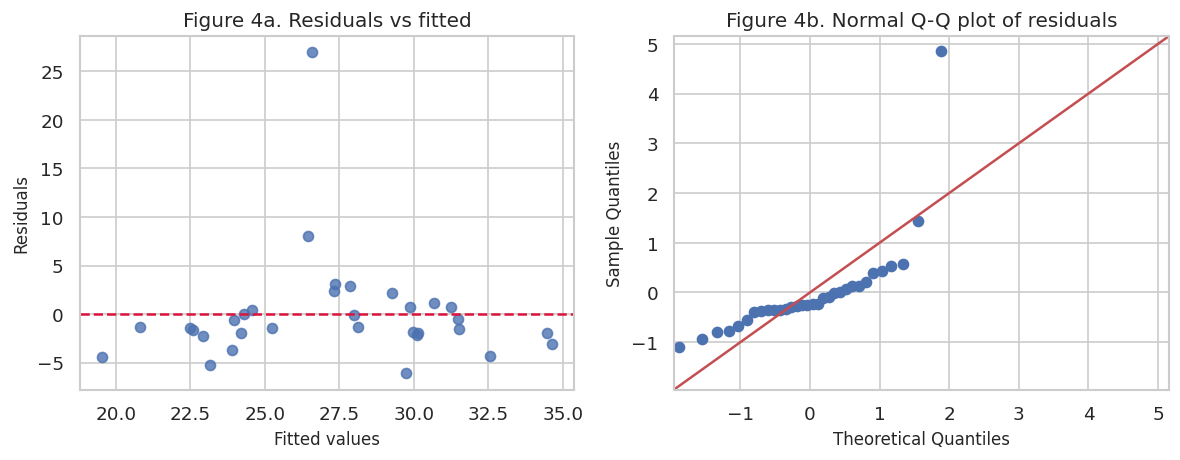

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(ols.fittedvalues, ols.resid, alpha=0.8)
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Figure 4a. Residuals vs fitted")

sm.qqplot(ols.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Figure 4b. Normal Q-Q plot of residuals")
plt.tight_layout()
plt.show()

In [ ]:
# (a) Log-linear specification, which addresses the right-skewed dependent variable
log_ols = sm.OLS(np.log(y), X).fit()
pct = (np.exp(log_ols.params.iloc[1]) - 1) * 100
print("(a) Log-linear model")
print(f"    coefficient = {log_ols.params.iloc[1]:.4f}  (p = {log_ols.pvalues.iloc[1]:.6f})")
print(f"    interpretation: +1 IMD point -> {pct:.2f}% higher violence rate")
print(f"    R-squared = {log_ols.rsquared:.3f}")

# (b) Huber robust regression, which down-weights rather than deletes outliers
rlm = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print("\n(b) Huber robust regression")
print(f"    coefficient = {rlm.params.iloc[1]:.3f}  (p = {rlm.pvalues.iloc[1]:.6f})")

# (c) Refit after excluding Westminster, the single influential observation
sub = df_model[df_model["borough"] != "Westminster"]
ols_sub = sm.OLS(sub["violence_rate_per_1000"],
                 sm.add_constant(sub["imd_score_2019"])).fit()
r_sub, p_sub = stats.pearsonr(sub["imd_score_2019"], sub["violence_rate_per_1000"])
print(f"\n(c) Excluding Westminster (n = {len(sub)})")
print(f"    Pearson r   = {r_sub:.3f}  (p = {p_sub:.6f})")
print(f"    coefficient = {ols_sub.params.iloc[1]:.3f}   R-squared = {ols_sub.rsquared:.3f}")

(a) Log-linear model
    coefficient = 0.0269  (p = 0.000016)
    interpretation: +1 IMD point -> 2.73% higher violence rate
    R-squared = 0.469

(b) Huber robust regression
    coefficient = 0.684  (p = 0.000000)

(c) Excluding Westminster (n = 31)
    Pearson r   = 0.829  (p = 0.000000)
    coefficient = 0.675   R-squared = 0.688


The OLS model gives a positive and highly significant coefficient for deprivation. Each additional IMD point is associated with 0.647 more violent offences per 1,000 residents (SE 0.170, p < 0.001, 95% CI 0.299 to 0.994). R² = 0.325 and adjusted R² = 0.303, meaning that deprivation explains roughly one third of the variation between boroughs.

The diagnostics support the model in one way but add an important qualification. The Breusch–Pagan test gives p = 0.815, so there is no evidence of heteroscedasticity and the reported standard errors are appropriate. However, Shapiro–Wilk rejects residual normality (p < 0.001). Figures 4a and 4b show the reason: Westminster is fitted at 26.60 offences per 1,000 but records 53.56, leaving a residual of +26.96. The next largest residual is Camden at +8.03. Most remaining residuals follow a near-linear pattern on the Q-Q plot, so the issue appears to be one influential observation rather than a general problem with the model.

All three robustness checks point in the same direction. The log-linear model gives R² = 0.469 and suggests that a one-point increase in IMD is associated with a 2.73% higher violence rate (p < 0.001). The Huber robust regression gives a coefficient of 0.684, which is very close to the OLS estimate of 0.647. This suggests that the slope is not simply caused by Westminster. When Westminster is excluded, r rises to 0.829 and R² to 0.688, with a coefficient of 0.675. Overall, the relationship remains robust in direction and size, although the amount of variance explained changes across specifications.

These results answer research Question 3. Deprivation is a consistent correlate of borough-level violence, but it does not explain all of the variation. Westminster's position is meaningful rather than simply a statistical problem. The resident denominator likely understates the population at risk in a borough shaped by the West End night-time economy, transport interchanges and high visitor numbers. This highlights a limitation of resident-based rates for central boroughs and points to other possible explanations, such as daytime population, land-use mix, transport accessibility and policing intensity.


<a id="sec6"></a>
## 6. Conclusion

[go back to the top](#top)

This notebook examined spatial inequalities in violence against the person across London boroughs using Metropolitan Police records for 2023, ONS mid-2023 population estimates and the IMD 2019 borough average score. After converting crime counts into offences per 1,000 residents, the results show a clear spatial pattern, with the highest borough recording about 3.5 times the rate of the lowest.

Deprivation is positively and significantly associated with violence rates. Pearson r = 0.570, Spearman rho = 0.746, and the OLS model suggests that deprivation explains roughly one third of the variation between boroughs. Each additional IMD point is associated with 0.647 more offences per 1,000 residents. The log-linear model, Huber robust regression and refit excluding Westminster all support the same general relationship, so the finding does not depend on one influential borough.

The analysis also has clear limits. Borough-level results are ecological, meaning they cannot explain neighbourhood processes or individual behaviour (Hipp, 2007). The deprivation measure is from 2019, while the crime and population data refer to 2023. Most importantly, resident-based denominators can understate the population at risk in central boroughs, which is where the model performs least well. Future work could use smaller units such as wards or LSOAs, which would provide more observations and better support the machine-learning methods taught in this module. It could also include variables for daytime population and land use.

Overall, the results support the idea that structural disadvantage and violence are spatially patterned together (Sampson et al., 1997). At the same time, they show that deprivation alone cannot fully explain London's uneven geography of violence.


<a id="sec7"></a>
## 7. References

[go back to the top](#top)

Hipp, J. R. (2007). Block, tract, and levels of aggregation: Neighborhood structure and crime and disorder as a case in point. *American Sociological Review*, 72(5), 659–680. https://doi.org/10.1177/000312240707200501

Sampson, R. J., Raudenbush, S. W., & Earls, F. (1997). Neighborhoods and violent crime: A multilevel study of collective efficacy. *Science*, 277(5328), 918–924. https://doi.org/10.1126/science.277.5328.918

Shaw, C. R., & McKay, H. D. (1942). *Juvenile delinquency and urban areas*. University of Chicago Press.

### Data sources

Greater London Authority. *Statistical GIS Boundary Files for London*. London Datastore. https://data.london.gov.uk/dataset/statistical-gis-boundary-files-london

Metropolitan Police Service / Greater London Authority. *MPS Recorded Crime: Geographic Breakdown*. London Datastore. https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m

Ministry of Housing, Communities & Local Government. (2019). *English Indices of Deprivation 2019* (London file). London Datastore. https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g

Office for National Statistics. (2024). *Estimates of the population for England and Wales: mid-2023*. https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/estimatesofthepopulationforenglandandwales